## El método de MonteCarlo WaveFunction

Es un método para simular un sistema pequeño acoplado a un reservorio grande, es decir un sistema cuantico abierto, usando funciones de onda (WF) en vez de el operador de densidad podemos disminuir el numero de componentes que se necesita calcular de $N^2 \rightarrow N$, esto mediante un hamiltoniano no hermitico y la evolucion consideramos saltos cuanticos aleatorios que originan las fluctuaciones y disipacion del sistema. Es equivalente a la ecuacion de Lindblad (Regimen Markoviano) tomando el promedio de las 'trayectorias' de la WF.

$$
\dot \rho_s = i [\rho_s, H_s] + \mathcal{L}_{\small relax}(\rho_s)
$$
Donde $\mathcal{L}_{\small relax}(\rho_s)$ es el superop. de relajacion, en el paper de Molmer utiliza ops. de relajacion tipo eq. de Lindblad. El método consiste en 2 pasos

- Evolucion con Hamiltoniano no hermitico y los saltos cuanticos aleatorios
- Renormalizacion de la WF

Consideramos el sig. Hamiltoniano, notar que $H\neq H^\dagger$ y suponemos que en un tiempo t (inicial) se encuentra en un estado puro la WF $\ket {\phi(t)}$
$$
H = H_s - \frac{i}{2} \sum C_m^\dagger C_m
$$
Entonces su evolucion para dt pequeños
$$
\ket {\phi^1(t+dt)} = \left( \mathbb I - i H dt\right)\ket \phi
$$

In [34]:
import numpy as np
from qutip import *
import sys 
np.set_printoptions(
    threshold=np.inf,      # Never truncate rows/columns
    linewidth=150,         # Max characters per line before wrapping
    precision=4,           # Number of decimal places
    suppress=True          # Suppress scientific notation (e.g., 1e-16 -> 0)
)

In [2]:


def MCWF_evolution(phi_0, H_S, L_ops, t_final, dt):
    """
    Evolución Monte Carlo Wave Function (MCWF).

    Parameters
    ----------
    phi_0   : Estado inicial ket phi(0).
    H_S     : Hamiltoniano del sistema pequeño.
    L_ops   : Lista de operadores de salto L_m.
    t_final : Tiempo final.
    dt      : Paso temporal.

    Returns
    -------
    resultados : Estados ket phi(t + dt) a cada paso temporal.
    """

    phi = phi_0.copy()
    resultados = []

    t = 0.0

    # Hamiltoniano no hermitico
    H = H_S.copy()

    for L in L_ops:
        H += -1j / 2 * (L.dag() @ L) # Suma L_m^dag L_m

    while t < t_final:

    # 1. Evolución 
        I = qeye(H_S.shape[0])
        phi_1 = (I - 1j * H * dt) @ phi

        # Probabilidades de salto
        delta_p_m = []

        for L in L_ops:
            # dt \bra{phi} L_m^dag L_m \ket{phi}
            v = (phi.dag() @ L.dag() @ L @ phi).real
            dp = dt*v                        # Calcula dp_m para todos los L
            delta_p_m.append(dp)             # Para cada m lo mete a esta lista, individual

        delta_p = sum(delta_p_m)

        # 2. Posible salto cuantico 
        epsilon = np.random.random()

        if epsilon > delta_p: # No ocurre 

            # El estado se normaliza, sin modificacion
            phi = phi_1 / np.sqrt(1 - delta_p)
        else: # Si ocurre 
            
            probs = np.array(delta_p_m) / delta_p
            m = np.random.choice(len(L_ops), p=probs)  # Toma cualquier (aleatoriamente) L ops
            L = L_ops[m]

            # Cambia el estado y su norma
            norma = np.sqrt(delta_p_m[m] / dt)
            phi = L @ phi / norma

        # Guardar estado 
        resultados.append(phi.copy())

        t += dt # aumenta el t

    return  np.array(resultados)



In [131]:
alpha = 0.1 - 0.5j

beta = np.sqrt(complex(1 - alpha * alpha.conjugate()))

print(beta * beta.conjugate())
print(alpha * alpha.conjugate())

(0.74+0j)
(0.26+0j)


# Sistema de 2 niveles del oscilador armonico
Acoplado a un baño de osciladores en su estado base (T=0 K) (Acoplamiento tipo emisión espontanea)

In [30]:
"""
two-level system of a harmonic oscillator with a spontaneous-emission like
coupling , i.e., a coupling to a bath of harmonic oscillators in its ground state (zero temperature). Molmer paper eq3
"""
N = 100# Espacio de Hilbert
ket0 = basis(N, 0) 
ket1 = basis(N,1)

# Parametros 
alpha = 0.1 - 0.5j
if np.abs(alpha) > 1:
    print('el modulo de alpha debe ser menor a 1')
    sys.exit()
else:
    beta = np.sqrt(complex(1 - alpha * alpha.conjugate()))
Gamma = 1 
omega_0 = 1
# Estado inicial
phi_0 = coherent(N, 1)


b = destroy(N)
I = qeye(N)
H_s = omega_0 * (b.dag() * b)
L_ops = [np.sqrt(Gamma) * b]

N_traj = [5, 20, 40, 60]

tray_n = []

for N in N_traj:

    trayectorias = []
    
    for i in range(N):

        trayectoria = MCWF_evolution(
            phi_0,
            H_s,
            L_ops,
            t_final=10,
            dt=0.005
        )

        trayectorias.append(trayectoria)

    tray_n.append(np.array(trayectorias))

print('finished')

finished


In [82]:
"""
Evolucion exacta de la ecuacion de Linblad para comparar
"""
t = np.arange(0, 5 + 0.005, 0.005)
rho_0 = phi_0*phi_0.dag()
n_op = [b.dag()*b]
evo1 = mesolve(H_s , rho_0, t, L_ops, n_op)

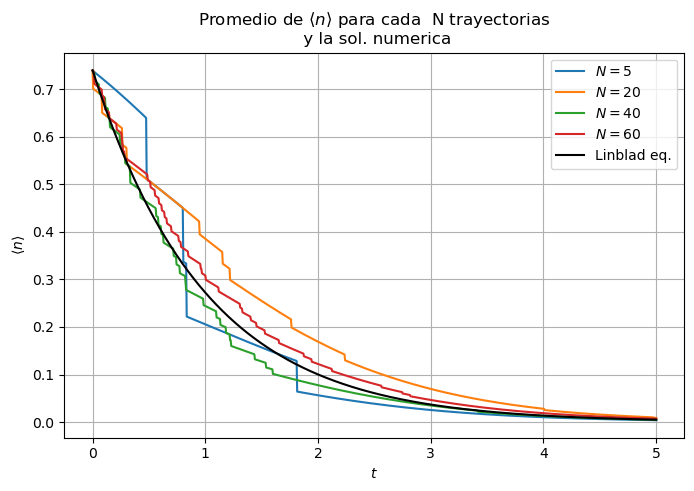

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for n in range(len(N_traj)):

    promedio = np.mean(
        [
            np.array([
                expect(n_op, phi)
                for phi in tray
            ])
            for tray in tray_n[n]
        ],
        axis=0
    )

    plt.plot(
        t,
        promedio,
        label=fr"$N={N_traj[n]}$"
    )
plt.plot(t, evo1.expect[0], c='black', label = 'Linblad eq.')

plt.title(r'Promedio de $\langle n \rangle$ para cada  N trayectorias ' + '\n y la sol. numerica')
plt.xlabel(r"$t$")
plt.ylabel(r"$\langle n \rangle$")
plt.legend()
plt.grid()

plt.savefig('HO_twolevels.pdf')
plt.show()



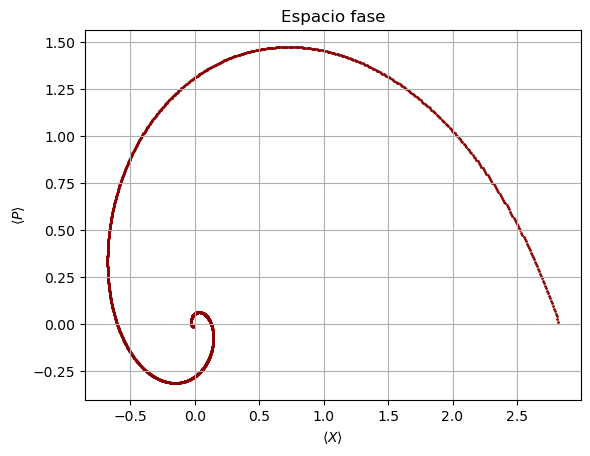

In [37]:
X = np.sqrt(2)*(b.dag() + b)
P = -1j*np.sqrt(2)*(b.dag() - b)

for n in range(len(N_traj)):
    Xprom = np.mean(
            [
                np.array([
                    expect(X, phi)
                    for phi in tray
                ])
                for tray in tray_n[n]
            ],
            axis=0
        )
    Pprom = np.mean(
            [
                np.array([
                    expect(P, phi)
                    for phi in tray
                ])
                for tray in tray_n[n]
            ],
            axis=0
        )

import matplotlib.pyplot as plt


plt.title('Espacio fase')
plt.grid(0.5)
plt.xlabel(r'$\langle X \rangle$')
plt.ylabel(r'$\langle P \rangle$')
plt.scatter(Xprom,Pprom, s= 1, c='darkred')

[-1.1068  0.4371  1.9816  3.5532  5.2523  7.2246  9.5682 12.3567 15.7191 20.014 ]


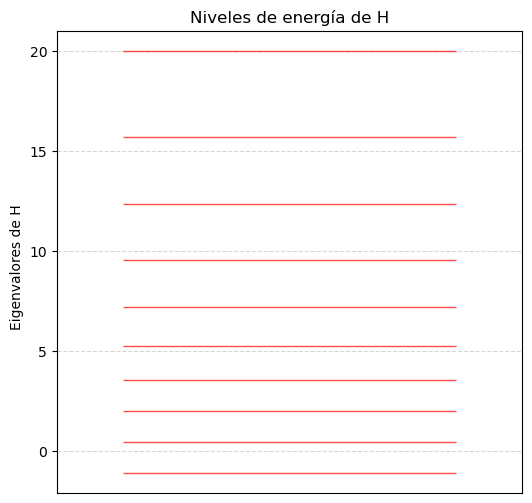

In [50]:
from qutip import *
n=10
b= destroy(n)
H_s = omega_0 * (b.dag() @ b + 1/2) + (0.2*np.sqrt(2)*(b.dag() + b)).sinm() + np.sqrt(2)*(b.dag() + b) 


eigs = H_s.eigenenergies()
print(eigs)
plt.figure(figsize=(6, 6))
plt.hlines(y=eigs, xmin=-5, xmax=5, colors='red', linewidth=1, alpha=0.7)

plt.title('Niveles de energía de H')
plt.ylabel('Eigenvalores de H  ')

plt.xticks([])
plt.xlim(-7, 7)
plt.ylim(eigs.min() - 1, eigs.max() + 1)
plt.grid(axis='y', linestyle='--', alpha=0.5) # Cuadrícula solo en el eje Y
plt.show()


# Oscilador amortiguado por un baño térmico a temp T.
El ejemplo anterior era el caso para un sistema de 2 niveles o de un oscilador armonico con un acoplamiento tipo emision espontanea, i.e., un acoplamiento a un baño de osciladores en su estado base (T = 0), para un reservorio con temperatura T el operador de relajacion se vuelve

$$
\mathcal L_{rlx}(\rho) = \frac{\Gamma}{2}[1 + n(\omega_0)](\sigma^-\rho\sigma^+ -\frac{1}{2}\{\sigma^+\sigma^-, \rho\}) + \frac{\Gamma}{2}[n(\omega_0)](\sigma^+\rho\sigma^- -\frac{1}{2}\{\sigma^-\sigma^+, \rho\})
$$
Con operadores de salto, que corresponden a una perdida por emision espontanea o por una emision estimulada ($L_1$) y una excitacion (ganancia) por absorción del reservorio ($L_2$)
$$
L_k = \left\{\sqrt{\Gamma[1+ n(\omega_0)]}\sigma^- , \sqrt{\Gamma n(\omega_0)}\sigma^+\right\}
$$
Donde $n(\omega_0)$ es la media de 'excited quanta' a temperatura T a la frecuencia de resonancia $\omega_0$ del sistema de 2 niveles o el oscilador

$$
n(\omega_0) = \left[\exp{\frac{\hbar\omega_0}{kT}-1}\right]^{-1}
$$
Tomando en cuenta que $\sigma^- =\rightarrow b$ Para un oscilador amortiguado por un baño térmico.

In [90]:
"""
Reservorio a una temperatura T: Oscilador amortiguado por un baño térmico.
"""

N = 100 # Espacio de Hilbert
ket0 = basis(N, 0) 
ket1 = basis(N,1)

# Parametros 
alpha = 0.35 - 0.2j
if np.abs(alpha) > 1:
    print('el modulo de alpha debe ser menor a 1')
    sys.exit()
else:
    beta = np.sqrt(complex(1 - alpha * alpha.conjugate()))
Gamma = 1 
omega_0 = 0.5
T = 1000
# Estado inicial
phi_0 = alpha*ket0 + beta*ket1


b = destroy(N)
I = qeye(N)
H_s = omega_0 * (b.dag() * b)

n_omega = (np.exp(omega_0/T))**(-1)

L_ops = [
        np.sqrt(Gamma*(1+ n_omega)) * b,
        np.sqrt(Gamma*n_omega) * b.dag()
        ]

N_traj = [40, 60,80,120]

tray_n = []

for N in N_traj:

    trayectorias = []
    
    for i in range(N):

        trayectoria = MCWF_evolution(
            phi_0,
            H_s,
            L_ops,
            t_final=10,
            dt=0.005
        )

        trayectorias.append(trayectoria)

    tray_n.append(np.array(trayectorias))

print('finished')

finished


In [91]:
"""
Evolucion exacta de la ecuacion de Linblad para comparar
"""
t = np.arange(0, 10 , 0.005)
rho_0 = phi_0*phi_0.dag()
n_op = [b.dag()*b]
evo = mesolve(H_s , rho_0, t, L_ops, n_op)

C:\Users\Arturo\.conda\envs\QMPhysics\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


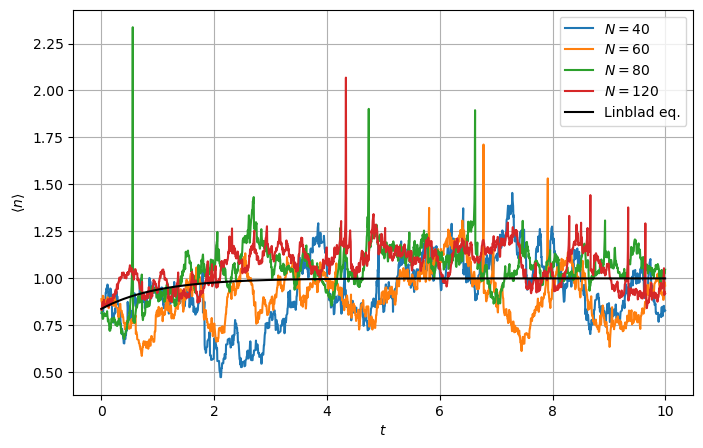

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for n in range(len(N_traj)):

    promedio = np.mean(
        [
            np.array([
                expect(n_op, phi)
                for phi in tray
            ])
            for tray in tray_n[n]
        ],
        axis=0
    )

    plt.plot(
        t,
        promedio,
        label=fr"$N={N_traj[n]}$"
    )
plt.plot(t, evo.expect[0], c='black', label = 'Linblad eq.')

#plt.ylim(0.6,1.5)
plt.xlabel(r"$t$")
plt.ylabel(r"$\langle n \rangle$")
plt.legend()
plt.grid()

plt.savefig('DampedHO_TReservoir.pdf')
plt.show()

# Reservorio con temp finita: Atomo de 2 niveles


In [41]:
"""
Reservorio a una temperatura T: Atomo de 2 niveles
"""

N = 2 # Espacio de Hilbert
ket0 = basis(N, 0) # up
ket1 = basis(N, 1) # down

# Parametros 
alpha = 0.35 - 0.2j
if np.abs(alpha) > 1:
    print('el modulo de alpha debe ser menor a 1')
    sys.exit()
else:
    beta = np.sqrt(complex(1 - alpha * alpha.conjugate()))
    
Gamma = 1 
omega_0 = 0.5
T = 500
# Estado inicial
phi_0 = alpha*ket0 + beta*ket1

# Operadores de spin
sig_ = sigmam()
I = qeye(N)
H_s = omega_0 * (sig_.dag() * sig_)

n_omega = (np.exp(omega_0/T))**(-1)

L_ops = [
        np.sqrt(Gamma*(1+ n_omega)) * sig_,
        np.sqrt(Gamma*n_omega) * sig_.dag()
        ]

N_traj = [40, 60,80,120]

tray_n = []

for N in N_traj:

    trayectorias = []
    
    for i in range(N):

        trayectoria = MCWF_evolution(
            phi_0,
            H_s,
            L_ops,
            t_final=5,
            dt=0.005
        )

        trayectorias.append(trayectoria)

    tray_n.append(np.array(trayectorias))

print('----------------------------finished MCWF----------------------------')

"""
Evolucion exacta de la ecuacion de Linblad para comparar
"""
t = np.arange(0, 5+0.005 , 0.005)
rho_0 = phi_0*phi_0.dag()

exp_ops = [sigmax()]
evo = mesolve(H_s , rho_0, t, L_ops, e_ops=exp_ops)

print('----------------------------finished integrating----------------------------')

----------------------------finished MCWF----------------------------
----------------------------finished integrating----------------------------


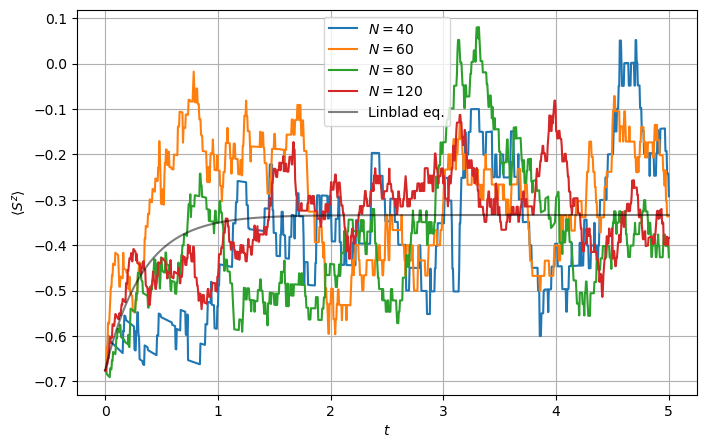

In [40]:
plt.figure(figsize=(8, 5))

for n in range(len(N_traj)):

    promedio = np.mean(
        [
            np.array([
                expect(exp_ops, phi)
                for phi in tray
            ])
            for tray in tray_n[n]
        ],
        axis=0
    )

    plt.plot(
        t,
        promedio,
        label=fr"$N={N_traj[n]}$"
    )
plt.plot(t, evo.expect[0], c='black', label = 'Linblad eq.', alpha=0.5)

#plt.ylim(0.6,1.5)
plt.xlabel(r"$t$")
plt.ylabel(r"$\langle S^z \rangle$")
plt.legend()
plt.grid()

plt.savefig('2lvlAtom.pdf')
plt.show()

# Esfera de Poincare

In [ ]:
alpha = 1 + 0.5j

phi = 
theta = 
psi = spin_coherent(1/2, theta, phi)